# 10 — TDA Comparison of Two Point Clouds

Use topological data analysis (scikit-TDA: `ripser` + `persim`) to compare two SciVer point clouds via **persistent homology**:

- **Cloud A — pair embeddings:** `pair_text_vec` (384-dim) for the 1500 claim/evidence pairs, read from the local Qdrant store. Cosine-normalized → cosine distance.
- **Cloud B — difficulty scores:** the 12 fully-scored difficulty dimensions (817 × 12) from `faithfulness_dataset.parquet`. Standardized → Euclidean distance.

We compute persistence diagrams, **barcodes**, and **Betti curves / discrete Betti numbers** for each, then compare them.

**Install (once):**
```bash
pip install ripser persim
```

> **Important caveat — read before interpreting.** The two clouds live in different ambient spaces (384-dim vs 12-dim), at different scales, with different sizes and meanings. Persistent homology is computed *per cloud*; comparing across spaces is only heuristic. To make the diagrams comparable we (a) subsample both to the same number of points and (b) normalize each distance matrix by its own maximum so the filtration axis is in [0, 1]. Even so, treat the comparison as a *shape summary*, not proof that the datasets are 'the same' or 'different'.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from persim import plot_diagrams, bottleneck

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "scripts").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))
import tda_point_clouds as tda

QDRANT_PATH = REPO_ROOT / "data" / "processed" / "qdrant_sciver"
FAITHFULNESS = REPO_ROOT / "data" / "processed" / "faithfulness_dataset.parquet"

SUBSAMPLE_N = 600      # points per cloud (matched, keeps H1 tractable)
SEED = 0
SIG_THRESHOLD = 0.10   # normalized persistence above which a feature is 'significant'
NULL_REPEATS = 5       # shuffled-feature baselines for significance context
MAXDIM = 1             # compute H0 and H1

## 2. Load and normalize the two point clouds

Embeddings come from Qdrant (not the manifest, which holds only metadata). Difficulty scores come from the faithfulness parquet. We subsample both to the same size and build normalized distance matrices with the metric appropriate to each space.

In [2]:
X_embed = tda.subsample(tda.load_embedding_cloud(QDRANT_PATH), SUBSAMPLE_N, seed=SEED)
X_diff = tda.subsample(tda.load_difficulty_cloud(FAITHFULNESS), SUBSAMPLE_N, seed=SEED)
print("embedding cloud:", X_embed.shape, "(cosine)")
print("difficulty cloud:", X_diff.shape, "(euclidean, standardized)")
print("exact-duplicate difficulty points:", len(X_diff) - len(np.unique(X_diff, axis=0)))

D_embed = tda.normalized_distance_matrix(X_embed, "cosine")
D_diff = tda.normalized_distance_matrix(X_diff, "euclidean")

embedding cloud: (600, 384) (cosine)
difficulty cloud: (600, 12) (euclidean, standardized)
exact-duplicate difficulty points: 68


## 3. Persistent homology

In [3]:
dgms_embed = tda.persistence(D_embed, maxdim=MAXDIM)
dgms_diff = tda.persistence(D_diff, maxdim=MAXDIM)

for name, dgms in [("embedding", dgms_embed), ("difficulty", dgms_diff)]:
    print(f"{name}: H0 bars={len(dgms[0])}, H1 bars={len(dgms[1])}")

embedding: H0 bars=600, H1 bars=1482
difficulty: H0 bars=539, H1 bars=511


## 4. Persistence diagrams

Points far from the diagonal are long-lived (potentially real) features; points hugging the diagonal are short-lived (topological noise).

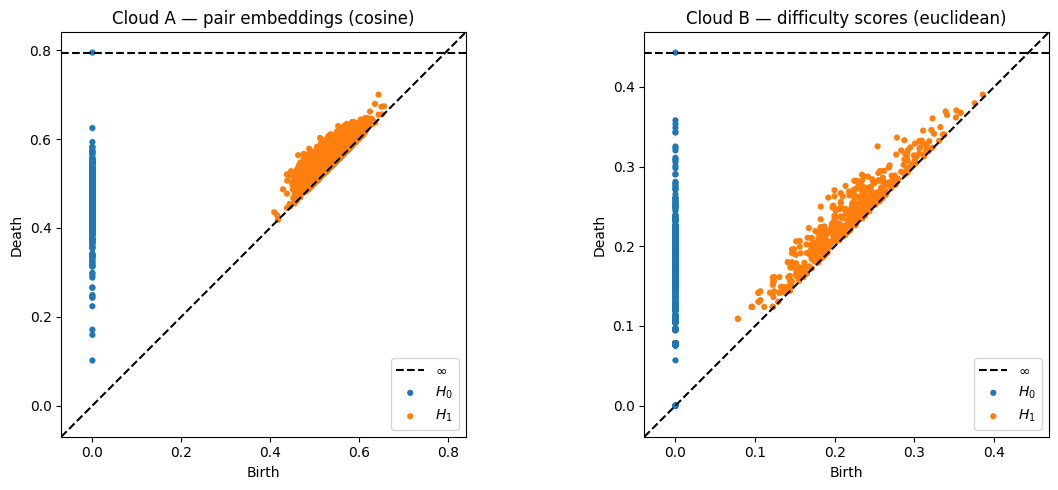

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_diagrams(dgms_embed, ax=axes[0], show=False)
axes[0].set_title("Cloud A — pair embeddings (cosine)")
plot_diagrams(dgms_diff, ax=axes[1], show=False)
axes[1].set_title("Cloud B — difficulty scores (euclidean)")
plt.tight_layout()
plt.show()

## 5. Barcodes

Each horizontal bar is a feature, drawn from its birth to its death along the (normalized) filtration. We show the longest bars per homology dimension for legibility (H0 = blue, H1 = orange).

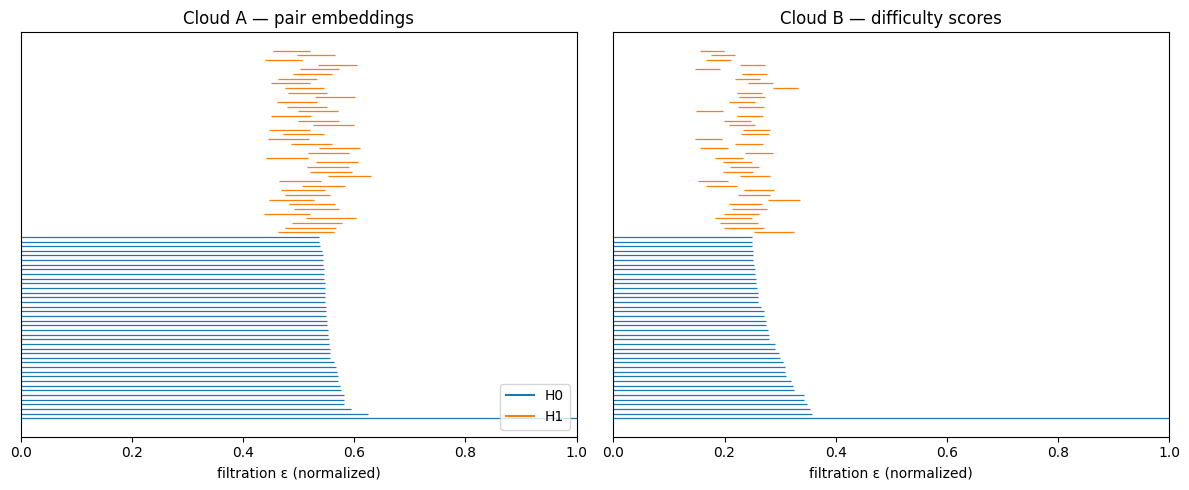

In [5]:
def plot_barcode(dgms, ax, title, cap=1.0, top_k=40):
    y = 0
    for k, dgm in enumerate(dgms):
        if len(dgm) == 0:
            continue
        deaths = np.where(np.isfinite(dgm[:, 1]), dgm[:, 1], cap)
        order = np.argsort(deaths - dgm[:, 0])[::-1][:top_k]
        for i in order:
            ax.hlines(y, dgm[i, 0], deaths[i], color=f"C{k}", lw=0.9)
            y += 1
    ax.set_title(title)
    ax.set_xlabel("filtration ε (normalized)")
    ax.set_yticks([])
    ax.set_xlim(0, cap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_barcode(dgms_embed, axes[0], "Cloud A — pair embeddings")
plot_barcode(dgms_diff, axes[1], "Cloud B — difficulty scores")
axes[0].plot([], [], "C0", label="H0"); axes[0].plot([], [], "C1", label="H1"); axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Betti curves and discrete Betti numbers

For a point cloud there is no single Betti number — it depends on the filtration scale ε. The **Betti curve** plots the Betti number as a function of ε. We also report a scale-robust **discrete** summary: the count of features whose persistence exceeds `SIG_THRESHOLD` (`b0`, `b1`).

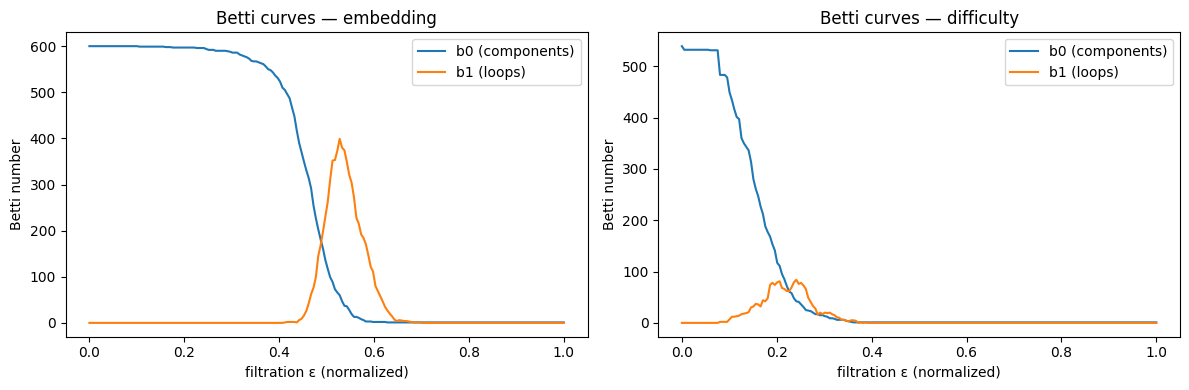

Discrete Betti numbers (features with persistence >= 0.1):
             b0  b1
embedding   599   1
difficulty  448   0


In [6]:
grid = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, dgms in [(axes[0], "embedding", dgms_embed), (axes[1], "difficulty", dgms_diff)]:
    ax.plot(grid, tda.betti_curve(dgms[0], grid), label="b0 (components)")
    ax.plot(grid, tda.betti_curve(dgms[1], grid), label="b1 (loops)")
    ax.set_title(f"Betti curves — {name}")
    ax.set_xlabel("filtration ε (normalized)"); ax.set_ylabel("Betti number")
    ax.legend()
plt.tight_layout()
plt.show()

sig = pd.DataFrame({
    "embedding": tda.significant_betti(dgms_embed, SIG_THRESHOLD),
    "difficulty": tda.significant_betti(dgms_diff, SIG_THRESHOLD),
}).T
print(f"Discrete Betti numbers (features with persistence >= {SIG_THRESHOLD}):")
print(sig.to_string())

## 7. Is any loop (H1) significant? A shuffled-feature baseline

The diagrams may show short H1 bars, but are they more than noise? We build a null cloud by independently permuting each feature column (destroying multivariate structure, keeping each feature's marginal distribution), recompute the longest H1 bar, and repeat. If the observed longest H1 bar does not exceed the null, there is no evidence of real loop structure.

In [7]:
def max_h1_persistence(D):
    h1 = tda.finite_bars(tda.persistence(D, maxdim=1)[1])
    return float((h1[:, 1] - h1[:, 0]).max()) if len(h1) else 0.0

def shuffled_null(X, metric, repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(repeats):
        Xs = np.column_stack([rng.permutation(col) for col in X.T])
        vals.append(max_h1_persistence(tda.normalized_distance_matrix(Xs, metric)))
    return np.array(vals)

for name, X, D, metric in [
    ("embedding", X_embed, D_embed, "cosine"),
    ("difficulty", X_diff, D_diff, "euclidean"),
]:
    observed = max_h1_persistence(D)
    null = shuffled_null(X, metric, NULL_REPEATS, seed=SEED)
    verdict = "ABOVE null (possible signal)" if observed > null.max() else "within null (noise)"
    print(f"{name:11s} observed max H1 = {observed:.3f} | null max = {null.max():.3f} -> {verdict}")

embedding   observed max H1 = 0.101 | null max = 0.061 -> ABOVE null (possible signal)
difficulty  observed max H1 = 0.072 | null max = 0.101 -> within null (noise)


## 8. Direct comparison of the diagrams

The **bottleneck distance** is the standard metric between two persistence diagrams: the largest distance you must move points (or push them to the diagonal) to match one diagram to the other. Because we normalized both filtrations to [0, 1], this is a comparable shape distance. We report it for H0 (connectivity) and H1 (loops).

In [8]:
bn_h0 = bottleneck(tda.finite_bars(dgms_embed[0]), tda.finite_bars(dgms_diff[0]))
bn_h1 = bottleneck(tda.finite_bars(dgms_embed[1]), tda.finite_bars(dgms_diff[1]))
print(f"bottleneck distance  H0 (components): {bn_h0:.3f}")
print(f"bottleneck distance  H1 (loops):      {bn_h1:.3f}")
print("\n(0 = identical shape; ~1 = maximally different on the normalized [0,1] axis.)")

bottleneck distance  H0 (components): 0.276
bottleneck distance  H1 (loops):      0.050

(0 = identical shape; ~1 = maximally different on the normalized [0,1] axis.)


## Conclusion

Fill in from the outputs above. Likely reading:

- **H1 (loops/holes):** if both clouds' longest H1 bars sit within their shuffled-feature null, neither point cloud has statistically meaningful loop structure — both are topologically 'blob-like' (contractible). High-dimensional embeddings are especially prone to this (distance concentration / curse of dimensionality), so a flat H1 is expected, not a bug.
- **H0 (connectivity):** the more informative difference. The Betti-0 curves describe how each cloud clusters as ε grows; the difficulty cloud also has exact-duplicate points (integer scores) that merge immediately.
- **Bottleneck distances** quantify how different the two diagrams' shapes are on the shared [0, 1] axis.

**What TDA can and cannot tell you here**
- It *can* summarize the multiscale connectivity/loop structure of each cloud and give a single distance between those summaries.
- It *cannot*, on its own, declare the datasets 'significantly different' across two unrelated spaces — the cross-space comparison depends on the normalization and subsampling choices above. Treat the result as descriptive.

**Sensitivity to check:** re-run with a larger `SUBSAMPLE_N`, a different `SEED`, other vectors (`claim_vec`, `image_vec`), or `MAXDIM=2` (H2 voids, slower) to see whether the qualitative picture holds.
